<a href="https://colab.research.google.com/github/sapunisandeepani123-netizen/Assignment-2/blob/main/Copy_of_Assignment2Fitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving crop_field.png to crop_field.png


In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Replace with your uploaded filename
img = cv.imread('your_image_name.png')

# Convert to grayscale (important for Canny)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


In [ ]:
print(uploaded.keys())

dict_keys(['crop_field.png'])


In [ ]:
img = cv.imread('crop_field.png')  # <-- match EXACT name

In [ ]:
print(img)

[[[ 98 122 104]
  [ 75 103  83]
  [ 77 113  91]
  ...
  [ 50  76 106]
  [ 55  81 111]
  [ 76 105 132]]

 [[ 48  74  58]
  [ 36  66  47]
  [ 26  64  42]
  ...
  [ 59  85 115]
  [ 74 100 130]
  [ 92 121 148]]

 [[  6  37  22]
  [  0  34  17]
  [  0  18   0]
  ...
  [ 57  83 113]
  [ 53  79 109]
  [ 51  79 109]]

 ...

 [[  0  55  19]
  [  0  68  32]
  [ 11 102  63]
  ...
  [  4  93  49]
  [  5  96  47]
  [ 36 122  74]]

 [[ 60 153 116]
  [ 57 152 115]
  [ 86 182 142]
  ...
  [  6  98  49]
  [ 27 119  68]
  [ 68 155 105]]

 [[ 36 132  95]
  [112 209 169]
  [ 81 180 140]
  ...
  [ 16 109  58]
  [ 34 126  73]
  [ 61 149  96]]]


In [ ]:
img = cv.imread('crop_field.png')

if img is None:
    raise ValueError("Image not loaded. Check filename or upload again.")

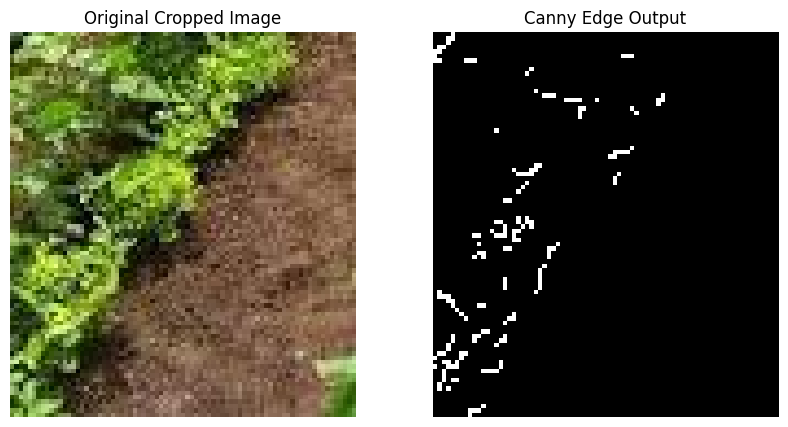

Slope (m): -0.9124360909577838
Angle (theta in radians): -0.7396435385348968
Angle (theta in degrees): -42.378453102171456


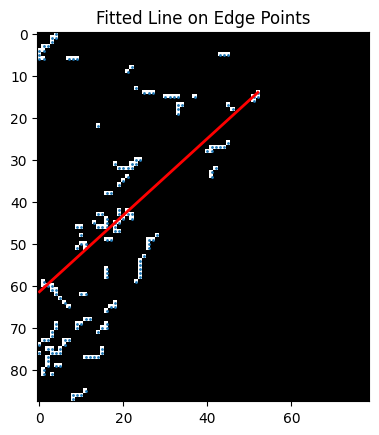

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv.imread('crop_field.png')  # <-- your filename
if img is None:
    raise ValueError("Image not loaded. Check filename.")

# Convert to grayscale
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Apply Canny edge detector
edges = cv.Canny(gray, 550, 690)

# Show images
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original Cropped Image")
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Canny Edge Output")
plt.imshow(edges, cmap='gray')
plt.axis('off')

plt.show()

# Extract edge coordinates
indices = np.where(edges != 0)
x = indices[1]
y = indices[0]

# Fit a line (y = mx + c)
m, c = np.polyfit(x, y, 1)

# Compute angle
theta_rad = np.arctan(m)
theta_deg = np.degrees(theta_rad)

# Print results
print("Slope (m):", m)
print("Angle (theta in radians):", theta_rad)
print("Angle (theta in degrees):", theta_deg)

# Plot fitted line
plt.imshow(edges, cmap='gray')
plt.scatter(x, y, s=1)

x_line = np.linspace(min(x), max(x), 100)
y_line = m * x_line + c

plt.plot(x_line, y_line, color='red', linewidth=2)
plt.title("Fitted Line on Edge Points")
plt.show()

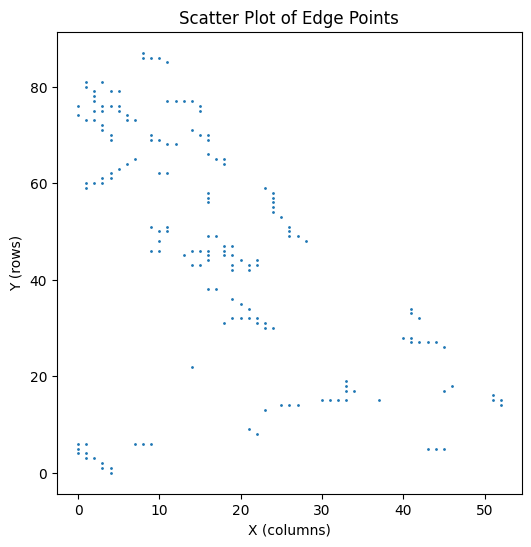

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(x, y, s=1)

plt.title("Scatter Plot of Edge Points")
plt.xlabel("X (columns)")
plt.ylabel("Y (rows)")

plt.show()

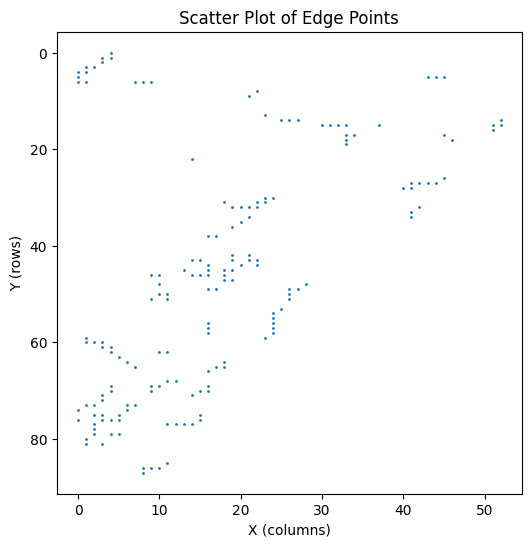

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(x, y, s=1)

plt.gca().invert_yaxis()  # <-- IMPORTANT

plt.title("Scatter Plot of Edge Points")
plt.xlabel("X (columns)")
plt.ylabel("Y (rows)")

plt.show()

In [ ]:
m, c = np.polyfit(x, y, 1)

In [ ]:
x_line = np.linspace(min(x), max(x), 100)
y_line = m * x_line + c

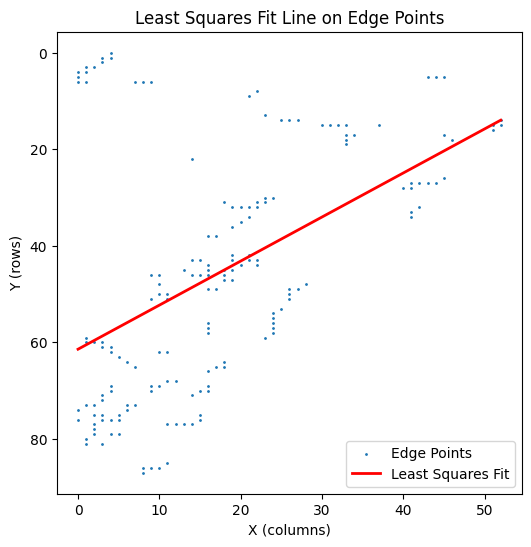

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

# Scatter points
plt.scatter(x, y, s=1, label='Edge Points')

# Fitted line
plt.plot(x_line, y_line, color='red', linewidth=2, label='Least Squares Fit')

# Fix orientation
plt.gca().invert_yaxis()

# Labels
plt.xlabel("X (columns)")
plt.ylabel("Y (rows)")
plt.title("Least Squares Fit Line on Edge Points")

plt.legend()
plt.show()

In [ ]:
theta_rad = np.arctan(m)
theta_deg = np.degrees(theta_rad)

In [ ]:
print("Slope (m):", m)

theta_rad = np.arctan(m)
theta_deg = np.degrees(theta_rad)

print("Theta (radians):", theta_rad)
print("Theta (degrees):", theta_deg)

Slope (m): -0.9124360909577838
Theta (radians): -0.7396435385348968
Theta (degrees): -42.378453102171456


In [ ]:
print(m)

-0.9124360909577838


Slope (m): -0.9124360909577838
Intercept (c): 61.41557108308582


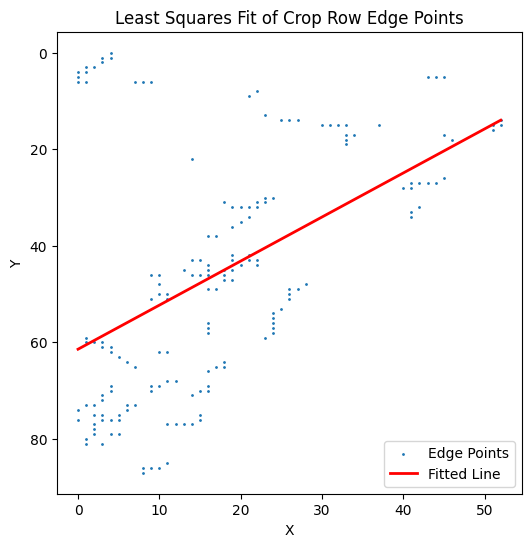

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Assume edges is your Canny output image
# Extract coordinates of edge pixels
y, x = np.where(edges != 0)

# Convert to numpy arrays
x = np.array(x)
y = np.array(y)

# Fit line using least squares (y = mx + c)
m, c = np.polyfit(x, y, 1)

print("Slope (m):", m)
print("Intercept (c):", c)

# Generate line values
x_line = np.linspace(min(x), max(x), 100)
y_line = m * x_line + c

# Plot scatter + fitted line
plt.figure(figsize=(6,6))
plt.scatter(x, y, s=1, label="Edge Points")
plt.plot(x_line, y_line, color='red', linewidth=2, label="Fitted Line")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Least Squares Fit of Crop Row Edge Points")
plt.legend()
plt.gca().invert_yaxis()  # Important for image coordinates
plt.show()

RANSAC Slope (m): -1.7027530828792652
RANSAC Intercept (c): 80.20489368675487


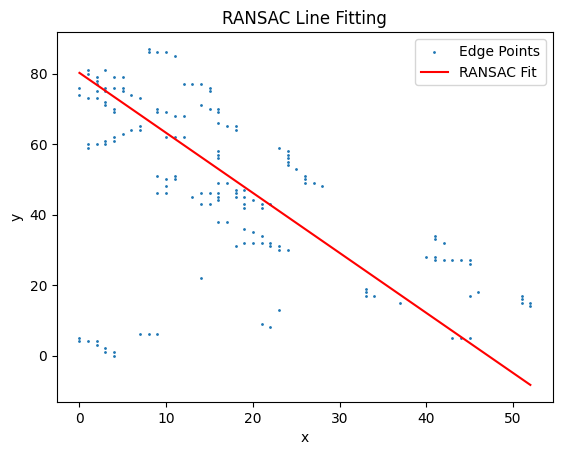

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor

# Load image
img = cv2.imread('crop_field.png', 0)

# Canny edge detection
edges = cv2.Canny(img, 550, 690)

# Extract coordinates
indices = np.where(edges != 0)
y = indices[0]
x = indices[1]

# Reshape for sklearn
x_reshaped = x.reshape(-1, 1)

# Apply RANSAC
ransac = RANSACRegressor()
ransac.fit(x_reshaped, y)

# Get slope and intercept
m_ransac = ransac.estimator_.coef_[0]
c_ransac = ransac.estimator_.intercept_

print("RANSAC Slope (m):", m_ransac)
print("RANSAC Intercept (c):", c_ransac)

# Generate line
line_x = np.linspace(min(x), max(x), 100)
line_y = m_ransac * line_x + c_ransac

# Plot
plt.scatter(x, y, s=1, label="Edge Points")
plt.plot(line_x, line_y, color='red', label="RANSAC Fit")
plt.legend()
plt.title("RANSAC Line Fitting")
plt.xlabel("x")
plt.ylabel("y")
plt.show()